In [6]:
%pip install scikit-image matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


# Trabajo Práctico 1: Búsqueda y Optimización

## Búsqueda Global

Un almacén tiene distribuidos 48 productos en 6 estanterías de 8 productos cada uno en una distribución como la que se puede observar en la imagen. Además, el almacén cuenta con una zona de carga señalizada como "C" en el diagrama:


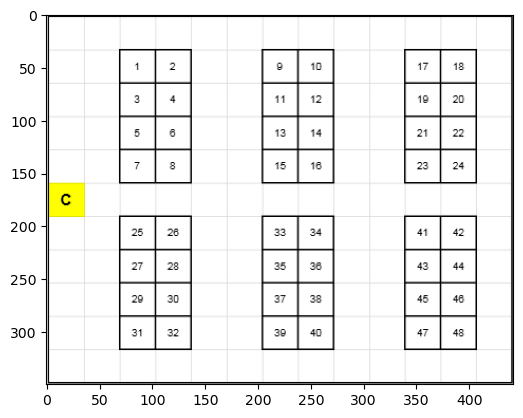

In [1]:
from skimage import io
import matplotlib.pyplot as plt

image = io.imread("https://drive.google.com/uc?export=view&id=1uXv0hJ7gNnpY_uErkTR-bcAlmq6VtbRV")
plt.imshow(image)
plt.show()

Programe el agente que usará el montacargas para navegar en el almacén usando un algoritmo A*. Tenga en cuenta las siguientes indicaciones:

* El agente solo puede moverse en los pasillos no ocupados por estantes

* El agente debe recibir como consigna la estantería a la que se desea mover el montacargas. Como la casilla numerada que reciba como consigna no es accesible, el agente debe detenerse en la casilla **horizontalmente adyacente** a la que tenga acceso

* El agente puede o no recibir una consigna de casilla inicial desde comenzar a navegar. En caso de que no se proporcione el dato, asuma que el movimiento se inicia en la estación de carga

* El costo de movimiento es uniforme. La heurística utilizada debe determinarla usted

Buscando ruta óptima hacia el estante 47.
Ruta óptima encontrada: [(10, 0), (10, 1), (10, 2), (10, 3), (10, 4), (10, 5), (10, 6), (10, 7), (10, 8), (9, 8), (9, 9)]
Costo de la ruta (pasos): 10


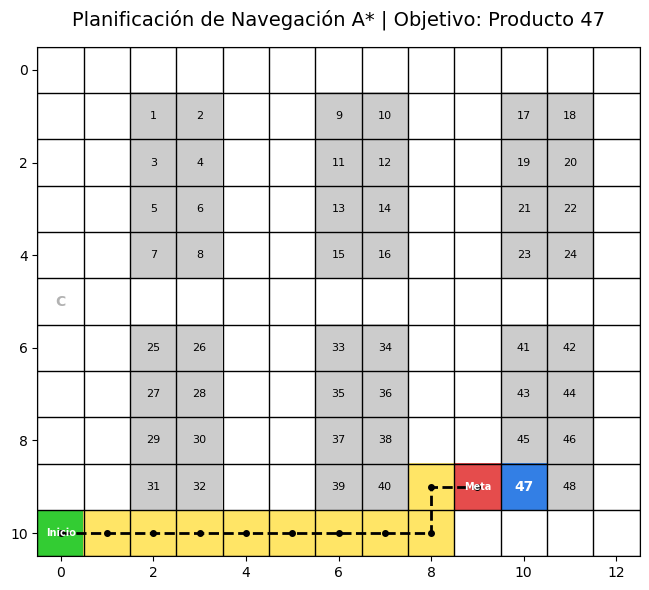

In [56]:
import heapq # Para importar la libreria de python mas completa, y utilizar heapq.heappop(), heapq.heappush(), etc.
import matplotlib.pyplot as plt
import numpy as np

class Nodo:
    """
    Clase fundamental que representa un estado en el espacio de búsqueda.
    """
    def __init__(self, posicion, padre=None):
        self.posicion = posicion  # Tupla (fila, columna)
        self.padre = padre        # Referencia al nodo anterior para reconstruir la ruta
        self.g = 0                # Costo desde el nodo inicial
        self.h = 0                # Valor de la heurística
        self.f = 0                # Costo total f(n) = g(n) + h(n)

    # Sobrecarga del operador "menor que" para que heapq ordene por el valor f(n) mejorada
     
    def __lt__(self, otro):
        # Si los costos totales son iguales, se evalúa el desempate
        if self.f == otro.f:
            # Desempate: priorizamos el nodo con menor distancia estimada a la meta
            return self.h < otro.h
        
        # Comportamiento normal: priorizar el menor costo total
        return self.f < otro.f

    # Método para comparar si dos nodos están en la misma posición
    def __eq__(self, otro):
        return self.posicion == otro.posicion


class AgenteAlmacen:
    """
    Agente racional encargado de navegar el almacén utilizando A*.
    """
    def __init__(self, mapa_almacen):
        self.mapa = mapa_almacen
        self.filas = len(mapa_almacen)
        self.columnas = len(mapa_almacen[0])
        self.estacion_carga = self._encontrar_casilla('C')

    def _encontrar_casilla(self, valor):
        """Busca y retorna las coordenadas (fila, col) de un valor específico en la matriz."""
        for i in range(self.filas):
            for j in range(self.columnas):
                if self.mapa[i][j] == valor:
                    return (i, j)
        return None

    def _obtener_metas_adyacentes(self, posicion_estante):
        """
        Determina las casillas horizontalmente adyacentes a un estante que sean transitables.
        Cumple con la consigna: "el agente debe detenerse en la casilla horizontalmente adyacente".
        """
        fila, col = posicion_estante
        metas_validas = []
        
        # Verificar adyacencia horizontal (Izquierda y Derecha)
        movimientos_horizontales = [(0, -1), (0, 1)]
        
        for df, dc in movimientos_horizontales:
            n_fila, n_col = fila + df, col + dc
            # Si está dentro de los límites y es un pasillo libre (0) o la estación ('C')
            if (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                if self.mapa[n_fila][n_col] == 0 or self.mapa[n_fila][n_col] == 'C':
                    metas_validas.append((n_fila, n_col))
                    
        return metas_validas

    def heuristica_manhattan(self, pos_actual, metas_posibles):
        """
        Calcula la distancia de Manhattan hacia la meta. Si hay múltiples metas posibles 
        (ej. izquierda y derecha del estante), toma la menor distancia.
        """
        distancias = []
        for meta in metas_posibles:
            dist = abs(pos_actual[0] - meta[0]) + abs(pos_actual[1] - meta[1])
            distancias.append(dist)
        return min(distancias)

    def buscar_ruta(self, id_estanteria, inicio=None):
        """
        Implementación del Algoritmo A* (Búsqueda Global Heurística).
        """
        # Si no se provee inicio, se asume la estación de carga "C"
        if inicio is None:
            inicio = self.estacion_carga

        # 1. Identificar la posición del producto/estantería
        pos_estante = self._encontrar_casilla(id_estanteria)
        if pos_estante is None:
            raise ValueError(f"La estantería {id_estanteria} no existe en el mapa.")

        # 2. Determinar las casillas meta (horizontalmente adyacentes)
        metas = self._obtener_metas_adyacentes(pos_estante)
        if not metas:
            raise ValueError("No hay casillas adyacentes accesibles para esta estantería.")

        # Inicializar listas Abierta (Priority Queue) y Cerrada (Set de visitados)
        nodo_inicio = Nodo(inicio)
        lista_abierta = []
        heapq.heappush(lista_abierta, nodo_inicio)
        lista_cerrada = set()

        # Definir los movimientos permitidos (Arriba, Abajo, Izquierda, Derecha)
        movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        # Bucle principal de A*
        while len(lista_abierta) > 0:
            # Extraer el nodo con el menor f(n)
            nodo_actual = heapq.heappop(lista_abierta)

            # Prueba de meta: ¿Hemos llegado a una casilla horizontalmente adyacente?
            if nodo_actual.posicion in metas:
                ruta = []
                actual = nodo_actual
                while actual is not None:
                    ruta.append(actual.posicion)
                    actual = actual.padre
                return ruta[::-1]  # Retornar la ruta invertida (desde el inicio hasta la meta)

            # Añadir a visitados
            lista_cerrada.add(nodo_actual.posicion)

            # Generar sucesores (expandir el nodo)
            for mov in movimientos:
                n_fila = nodo_actual.posicion[0] + mov[0]
                n_col = nodo_actual.posicion[1] + mov[1]
                pos_sucesora = (n_fila, n_col)

                # Restricciones del entorno: límites del mapa y obstáculos
                if (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                    # Solo nos movemos por pasillos (0) o la estación ('C')
                    if self.mapa[n_fila][n_col] == 0 or self.mapa[n_fila][n_col] == 'C':
                        
                        if pos_sucesora in lista_cerrada:
                            continue

                        # Crear nodo sucesor
                        sucesor = Nodo(pos_sucesora, nodo_actual)
                        sucesor.g = nodo_actual.g + 1 # Costo uniforme
                        sucesor.h = self.heuristica_manhattan(sucesor.posicion, metas)
                        sucesor.f = sucesor.g + sucesor.h

                        # Verificar si un nodo con esta posición ya está en la lista abierta con menor costo
                        # Para simplificar en Python, buscamos si ya existe y si es mejor
                        en_abierta_con_menor_costo = False
                        for nodo_abierto in lista_abierta:
                            if sucesor == nodo_abierto and sucesor.g >= nodo_abierto.g:
                                en_abierta_con_menor_costo = True
                                break
                        
                        if not en_abierta_con_menor_costo:
                            heapq.heappush(lista_abierta, sucesor)

        return None # Falla: No se encontró ruta


def visualizar_almacen_y_ruta(mapa_almacen, ruta, id_objetivo, metas, inicio):
    """
    Renderiza gráficamente el almacén, los obstáculos y la ruta óptima encontrada.
    
    Parámetros:
    - mapa_almacen: Lista de listas representando la matriz del entorno.
    - ruta: Lista de tuplas (fila, columna) que conforman el camino hallado por A*.
    - id_objetivo: El número entero del producto/estantería buscado.
    - inicio: Tupla (fila, columna) indicando la posición de partida.
    - metas: Lista de tuplas con las casillas adyacentes válidas para detenerse.
    """
    
    # 1. Extraer dimensiones del mapa
    filas = len(mapa_almacen)
    columnas = len(mapa_almacen[0])
    
    # 2. Inicializar una matriz de imagen RGB en blanco (1.0, 1.0, 1.0)
    # np.ones crea una matriz llena de unos. Multiplicamos dimensiones por 3 canales (R, G, B)
    imagen = np.ones((filas, columnas, 3))
    
    # 3. Definición de la paleta de colores (Valores RGB normalizados entre 0 y 1)
    color_pasillo = [1.0, 1.0, 1.0]     # Blanco
    color_estante = [0.8, 0.8, 0.8]     # Gris claro
    color_inicio = [0.2, 0.8, 0.2]      # Verde
    color_meta = [0.9, 0.3, 0.3]        # Rojo
    color_objetivo = [0.2, 0.5, 0.9]    # Azul
    color_ruta = [1.0, 0.9, 0.4]        # Amarillo pastel
    
    # 4. Configurar la figura de Matplotlib
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 5. Mapear la matriz lógica a la matriz visual e insertar etiquetas de texto
    for i in range(filas):
        for j in range(columnas):
            celda = mapa_almacen[i][j]
            
            # Condición A: Es un pasillo
            if celda == 0:
                imagen[i, j] = color_pasillo
                
            # Condición B: Es la estación de carga originaria
            elif celda == 'C':
                # Lo pintamos temporalmente como pasillo; el inicio real se sobreescribirá luego
                imagen[i, j] = color_pasillo 
                ax.text(j, i, 'C', ha='center', va='center', color='black', fontweight='bold', alpha=0.3)
                
            # Condición C: Es una estantería (obstáculo)
            else: 
                if celda == id_objetivo:
                    imagen[i, j] = color_objetivo # Destacar el estante buscado
                    ax.text(j, i, str(celda), ha='center', va='center', color='white', fontweight='bold')
                else:
                    imagen[i, j] = color_estante  # Estantes comunes
                    ax.text(j, i, str(celda), ha='center', va='center', color='black', fontsize=8)
    
    # 6. Colorear casillas meta (las adyacentes horizontalmente)
    for m in metas:
        imagen[m[0], m[1]] = color_meta
        ax.text(m[1], m[0], 'Meta', ha='center', va='center', color='white', fontsize=7, fontweight='bold')
        
    # 7. Colorear la posición de inicio del agente
    imagen[inicio[0], inicio[1]] = color_inicio
    ax.text(inicio[1], inicio[0], 'Inicio', ha='center', va='center', color='white', fontsize=7, fontweight='bold')

    # 8. Renderizar el camino sobre la matriz (si se encontró una ruta)
    if ruta:
        # Colorear las celdas de la ruta (omitiendo inicio y fin para no borrar sus colores)
        for paso in ruta[1:-1]:
            imagen[paso[0], paso[1]] = color_ruta
            
        # Trazar una línea conectora para visualizar claramente la trayectoria
        # Extraemos las coordenadas X (columnas) e Y (filas) de la ruta
        y_ruta = [p[0] for p in ruta]
        x_ruta = [p[1] for p in ruta]
        ax.plot(x_ruta, y_ruta, color='black', linewidth=2, linestyle='--', marker='.', markersize=8)

    # 9. Mostrar la imagen construida
    ax.imshow(imagen)
    
    # 10. Estética de la grilla: Añadir líneas divisorias para enmarcar las celdas
    # Desplazamos los ticks -0.5 para que las líneas de la grilla coincidan con los bordes de la celda
    ax.set_xticks(np.arange(-0.5, columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", size=0) # Ocultar las marcas del eje menor
    
    # Título dinámico
    ax.set_title(f"Planificación de Navegación A* | Objetivo: Producto {id_objetivo}", fontsize=14, pad=15)
    
    # Mostrar el gráfico de forma interactiva
    plt.tight_layout()
    plt.show()

# Leyenda:
# 0   = Pasillo transitable (espacio vacío)
# 'C' = Zona de carga (punto de inicio por defecto)
# 1 al 48 = IDs de los productos en las estanterías (obstáculos no transitables)

matriz_almacen = [
    # Pasillo superior
    [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
    
    # Estanterías 1 y 2
    [ 0,   0,   1,   2,   0,   0,   9,  10,   0,   0,  17,  18,   0 ],
    [ 0,   0,   3,   4,   0,   0,  11,  12,   0,   0,  19,  20,   0 ],
    [ 0,   0,   5,   6,   0,   0,  13,  14,   0,   0,  21,  22,   0 ],
    [ 0,   0,   7,   8,   0,   0,  15,  16,   0,   0,  23,  24,   0 ],
    
    # Pasillo central
    [ 'C', 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
    
    # Estanterías 3 y 4
    [ 0,   0,  25,  26,   0,   0,  33,  34,   0,   0,  41,  42,   0 ],
    [ 0,   0,  27,  28,   0,   0,  35,  36,   0,   0,  43,  44,   0 ],
    [ 0,   0,  29,  30,   0,   0,  37,  38,   0,   0,  45,  46,   0 ],
    [ 0,   0,  31,  32,   0,   0,  39,  40,   0,   0,  47,  48,   0 ],
    
    # Pasillo inferior
    [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ]
]

# 1. Instanciar el agente con el mapa
agente = AgenteAlmacen(matriz_almacen)

# Enviamos explícitamente la coordenada inicial
coordenada_actual = (10, 0)

# 2. Ejecutar búsqueda sin posición inicial explícita (tomará 'C' por defecto)
producto_objetivo = 47
ruta_encontrada = agente.buscar_ruta(producto_objetivo, inicio = coordenada_actual)

print(f"Buscando ruta óptima hacia el estante {producto_objetivo}.")
if ruta_encontrada:
    print(f"Ruta óptima encontrada: {ruta_encontrada}")
    print(f"Costo de la ruta (pasos): {len(ruta_encontrada) - 1}")
else:
    print("No se encontró una ruta factible.")

# Extraemos la información necesaria del agente para graficar:
posicion_estante = agente._encontrar_casilla(producto_objetivo)
metas_posibles = agente._obtener_metas_adyacentes(posicion_estante)
if coordenada_actual is None:
    inicio_utilizado = agente.estacion_carga
else:
    inicio_utilizado = coordenada_actual

# Llamada a la función gráfica:
visualizar_almacen_y_ruta(matriz_almacen, ruta_encontrada, producto_objetivo, metas_posibles, inicio_utilizado)




## Entorno dinámico

Ahora considere que hay dos montacargas funcionando a la vez. Incorpore a su algoritmo la lógica que permite evitar colisiones entre los agentes y recalcular las rutas necesarias. Suponga que tiene disponible cualquier sensor que se imagine que necesite para recalcular la ruta.

## Búsqueda local

Dada una orden de pedido, que incluye una lista de productos del almacén que deben ser despachados en su totalidad, determinar el orden óptimo para la operación de *picking* usando el algoritmo de Temple Simulado.

Puede usar cualquiera de las órdenes en el archivo `ordenes.csv` que puede descargar [haciendo click aquí](https://drive.google.com/uc?export=download&id=18efHvMnh8-WbFAhAixnYQepMXRg2fx7T) o crear una órden personalizada de su elección.

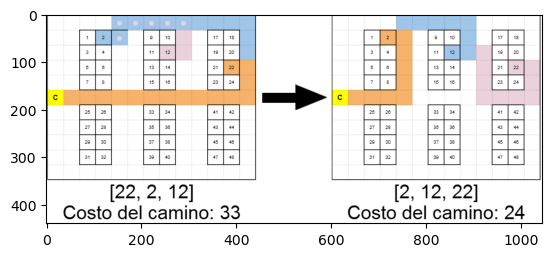

In [57]:
image = io.imread("https://drive.google.com/uc?export=view&id=13IxoBK-28xVqyiD-mve5IZD7hZT3Nq9W")
plt.imshow(image)
plt.show()

## Algoritmos Genéticos

Dado el histórico de órdenes pedidas (que puede encontrar en el archivo `ordenes.csv` que puede descargar [haciendo click aquí](https://drive.google.com/uc?export=download&id=18efHvMnh8-WbFAhAixnYQepMXRg2fx7T)), implemente un algoritmo genético para optimizar la ubicación de los productos en el almacén, de manera que **los productos pedidos con más frecuencia se ubiquen más cerca de la estación de carga**. Considere que la operación de picking comienza y termina en la estación de carga.

Una vez que el algoritmo determine una configuración de productos, realize un diagrama del almacén con la nueva configuración de productos que tenga un mapa de calor para graficar la frecuencia con la que cada producto es solicitado.

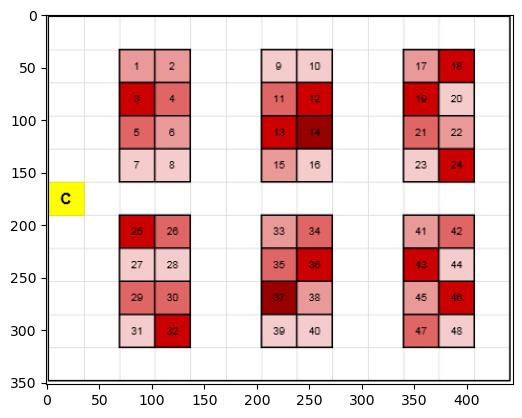

In [58]:
image = io.imread("https://drive.google.com/uc?export=view&id=1PHW426bY8Q31gBqEsvE5FFzhGnTuvjox")
plt.imshow(image)
plt.show()